## CLEANING MESSY RETAIL SALES DATASET 

##### 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### 2. LOAD DATA FROM CSV FILE

In [2]:
file_path = 'messy_retail_sales_dataset.csv' 
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded {file_path}. Dataset shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the file path.")
    exit()

Successfully loaded messy_retail_sales_dataset.csv. Dataset shape: (100, 11)


##### 3. DATA CLEANING & UNIT-SAFE TITLE CASING

In [3]:
def clean_product_name(name):
    if pd.isna(name):
        return name
    name = str(name).strip()
    titled = name.title()
    
    # Preserve standard unit abbreviations from title case distortion
    unit_replacements = {
        ' 2L': ' 2L',
        ' 1L': ' 1L',
        ' 10Kg': ' 10kg',
        ' 410G': ' 410g',
        ' 2Kg': ' 2kg',
        ' 500Ml': ' 500ml'
    }
    for wrong, right in unit_replacements.items():
        titled = titled.replace(wrong, right)
    return titled

# 1. Apply cleaning steps
df['product_name'] = df['product_name'].apply(clean_product_name)
df['category'] = df['category'].astype(str).str.strip().str.title()

# 2. Replace text placeholders with true NaN values
df.replace(['N/A', 'n/a', 'NA', '', 'nan'], np.nan, inplace=True)

# 3. Parse mixed date formats robustly (ISO, European, text dates)
df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')

# 4. Convert numeric columns
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')

# 5. Handle negative return quantities and round unit prices to 2 decimal places
df['quantity_cleaned'] = df['quantity'].abs().fillna(1)
df['unit_price'] = df['unit_price'].round(2)

# ==========================================
# SHOW RESULTS IN THE CONSOLE
# ==========================================
print("=== DATA CLEANING RESULTS PREVIEW ===")
# Select key columns to display side-by-side so you can verify the output
preview_cols = ['date', 'product_name', 'category', 'quantity_cleaned', 'unit_price']
print(df[preview_cols].head(10).to_string(index=False))

# Optional: Print summary information about missing values and row counts
print("\n=== DATASET INFO ===")
print(df.info())

=== DATA CLEANING RESULTS PREVIEW ===
      date             product_name  category  quantity_cleaned  unit_price
2026-03-01    Organic Whole Milk 2L     Dairy               2.0       45.50
2026-03-15          Maize Meal 10kg Groceries               1.0      120.00
2026-03-18  Canned Baked Beans 410g Groceries               6.0       18.99
2026-03-22 Sunflower Cooking Oil 2L Groceries               2.0       85.00
2026-03-25       Washing Powder 2kg Household               1.0       45.00
2026-03-28         Brown Bread 700G    Bakery               3.0       19.99
2026-04-02      Cheddar Cheese 500G     Dairy               1.0       79.50
2026-04-05     Sparkling Water 1.5L Beverages              12.0       12.50
2026-04-10     Instant Noodles Pack Groceries              20.0        5.00
2026-04-14   Energizing Drink 500ml Beverages               4.0        2.50

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column

##### 4. MULTI-CURRENCY NORMALIZATION (TO ZAR)

In [4]:
exchange_rates = {
    'ZAR': 1.0,
    'BWP': 1.35,
    'NAD': 1.0,
    'ZMW': 0.70,
    'USD': 18.50
}

df['exchange_rate'] = df['currency'].map(exchange_rates).fillna(1.0)
df['total_revenue_zar'] = df['quantity_cleaned'] * df['unit_price'] * df['exchange_rate']

# Save the cleaned dataset to a new CSV file
df.to_csv('retail_sales_cleaned.csv', index=False)
print("Cleaned dataset successfully exported to 'retail_sales_cleaned.csv'")

Cleaned dataset successfully exported to 'retail_sales_cleaned.csv'


##### 5. GROUPING & AGGREGATION

In [5]:
# 1. Group and aggregate your cleaned dataframe to create summary_df
summary_df = df.groupby(['country', 'category']).agg(
    total_transactions=('transaction_id', 'count'),
    total_quantity_sold=('quantity_cleaned', 'sum'),
    total_revenue_zar=('total_revenue_zar', 'sum'),
    avg_revenue_zar=('total_revenue_zar', 'mean')
).reset_index().sort_values(by='total_revenue_zar', ascending=False)

# 2. Round numeric values to 2 decimal places for mathematical accuracy
summary_df['total_revenue_zar'] = summary_df['total_revenue_zar'].round(2)
summary_df['avg_revenue_zar'] = summary_df['avg_revenue_zar'].round(2)

# 3. Create formatted display columns with currency symbols and thousands separators
summary_df['total_revenue_display'] = summary_df['total_revenue_zar'].map('R{:,.2f}'.format)
summary_df['avg_revenue_display'] = summary_df['avg_revenue_zar'].map('R{:,.2f}'.format)

# 4. Print the final results to your console
print("=== AGGREGATED SALES SUMMARY (ZAR) ===")
print(summary_df[['country', 'category', 'total_transactions', 'total_revenue_display', 'avg_revenue_display']].to_string(index=False))

=== AGGREGATED SALES SUMMARY (ZAR) ===
     country  category  total_transactions total_revenue_display avg_revenue_display
    Zimbabwe Groceries                  11             R1,524.40             R138.58
    Botswana Groceries                  10             R1,046.92             R104.69
    Zimbabwe Household                   4             R1,018.42             R254.61
South Africa     Dairy                  10               R920.92              R92.09
      Zambia Groceries                  12               R888.65              R74.05
     Namibia Household                   8               R887.94             R110.99
     Namibia Groceries                   6               R507.93              R84.66
    Botswana      Meat                   2               R438.75             R219.38
     Namibia Beverages                   4               R437.00             R109.25
    Botswana     Dairy                   3               R370.58             R123.53
      Zambia      Meat    

##### 6. SEABORN VISUALIZATION (BAR CHART)


Visualization saved successfully as 'sales_by_country_category.png'


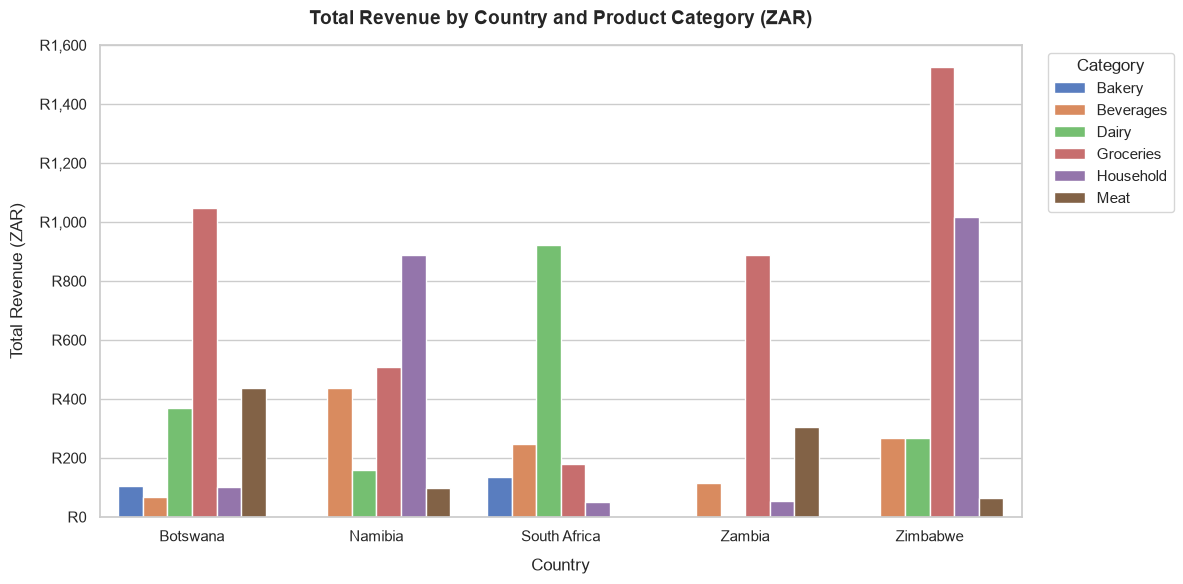

In [6]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

chart_data = df.groupby(['country', 'category'], as_index=False)['total_revenue_zar'].sum()

ax = sns.barplot(
    data=chart_data,
    x='country',
    y='total_revenue_zar',
    hue='category',
    palette='muted'
)

plt.title('Total Revenue by Country and Product Category (ZAR)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Country', fontsize=12, labelpad=10)
plt.ylabel('Total Revenue (ZAR)', fontsize=12, labelpad=10)

# Format y-axis with comma separators
ax.yaxis.set_major_formatter('R{x:,.0f}')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('sales_by_country_category.png', dpi=300)
print("\nVisualization saved successfully as 'sales_by_country_category.png'")
plt.show()